In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import arviz as az
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import KFold, cross_val_score


gdf = gpd.read_file(r"../data/updated_data.geojson")

#fem_house_rate has been deleted because it is obvious that if fem_house_rate is high, ratio_fem_mal will be low
col_to_del_linear_model=['rip_code','reg_code','prov_code','prov_area_code', 'prov_type','geo_point_2d','urban_type','private_coverage','fem_house_rate']
gdf.drop(columns=col_to_del_linear_model,inplace=True)



In [13]:
corr_xy = gdf['fem_empl_rate'].corr(gdf['empl_rate'])
print(corr_xy)
gdf['ratio_fem_mal']=gdf['fem_empl_rate']/gdf['mal_empl_rate']

gdf['ratio_edu_rate']=gdf['fem_edu_rate']/gdf['male_edu_rate']

0.9875395792383556


In [25]:
X=gdf.select_dtypes(include='number').drop(columns=['fem_empl_rate','mal_empl_rate','ratio_fem_mal','fem_edu_rate','male_edu_rate'])
y=gdf['ratio_fem_mal']


# Correlation Part

In [15]:
import numpy as np

#THRESHOLD=0.9, each variable has been deleted one by one by keeping 'empl_rate' (because it's easy to interprate empl_rate)
X.drop(columns=['other_per_capita_expenditure','inact_rate','adj_net_migration_rate','part_rate','unempl_rate'],inplace=True)

corr_matrix=X.corr()

upper_matrix = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

stacked=upper_matrix.stack()
best_pair = stacked.abs().idxmax()
best_corr_value = stacked.loc[best_pair]

print('best_pair',best_pair,'best_corr_value',best_corr_value)


best_pair ('young_neet', 'empl_rate') best_corr_value -0.899905224315081


In [26]:
#there is one missing value on ecec_diffusion variable
print(X.isna().sum())
X["ecec_diffusion"] = X["ecec_diffusion"].fillna(X["ecec_diffusion"].median())


population                            0
unempl_rate                           0
part_rate                             0
empl_growth                           0
inact_rate                            0
service_empl_rate                     0
GDP                                   0
n_large_comp                          0
n_self_empl                           0
young_neet                            0
foreign_rate                          0
n_members_family                      0
elderly_in_care                       0
house_price                           0
fertility_rate                        0
first_birth_maternal_age              0
avg_children_per_woman                0
dependency_rate                       0
ageing_index                          0
net_migration_rate                    0
adj_net_migration_rate                0
area_km2                              0
public_transport_supply               0
internet_coverage_rate                0
graduate_mobility_rate                0


In [17]:


selected_covariates=X.columns

X = X.to_numpy()
y = y.to_numpy()

print(y.shape)

# standardize predictors and the target
X_scaler = StandardScaler()
X_scaled = X_scaler.fit_transform(X)

y_mean = y.mean()
y_std = y.std()
y_scaled = (y - y_mean) / y_std

n_obs, n_feat = X_scaled.shape
print(f"\nNumber of observations: {n_obs}, number of predictors: {n_feat}")


(107,)

Number of observations: 107, number of predictors: 38


# Frequentist Lasso (Credits : Chi)

Best alpha found: 0.0035

Mean CV R²: 0.815 ± 0.089
Mean CV MSE: 0.002 ± 0.001


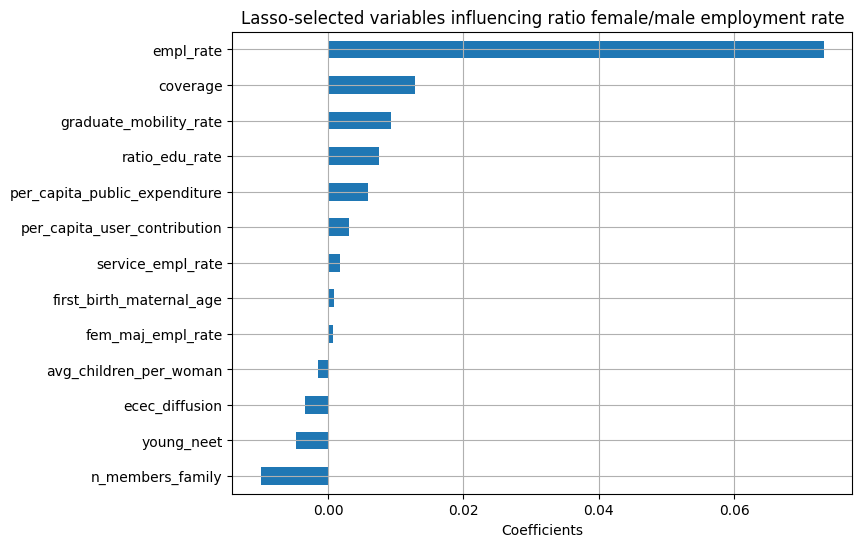

In [18]:


cv = KFold(n_splits=10, shuffle=True, random_state=42)
lasso_cv = LassoCV(cv=cv, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"Best alpha found: {lasso_cv.alpha_:.4f}")

lasso_final = Lasso(alpha=lasso_cv.alpha_)
lasso_final.fit(X_scaled, y)

coef = pd.Series(lasso_final.coef_, index=selected_covariates)
nonzero_coef = coef[coef != 0].sort_values(ascending=False)
# print("\nNon-zero coefficients (variables selected by Lasso):")
# print(nonzero_coef)

r2_scores = cross_val_score(lasso_final, X_scaled, y, cv=cv, scoring='r2')
mse_scores = -cross_val_score(lasso_final, X_scaled, y, cv=cv, scoring='neg_mean_squared_error')
print(f"\nMean CV R²: {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"Mean CV MSE: {np.mean(mse_scores):.3f} ± {np.std(mse_scores):.3f}")

plt.figure(figsize=(8,6))
nonzero_coef.sort_values().plot(kind='barh')
plt.title('Lasso-selected variables influencing ratio female/male employment rate')
plt.xlabel('Coefficients')
plt.grid(True)
plt.show()

/var/folders/y9/rry2kyrd4wlb4xwqx57mrs540000gn/T/ipykernel_64960/562960270.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


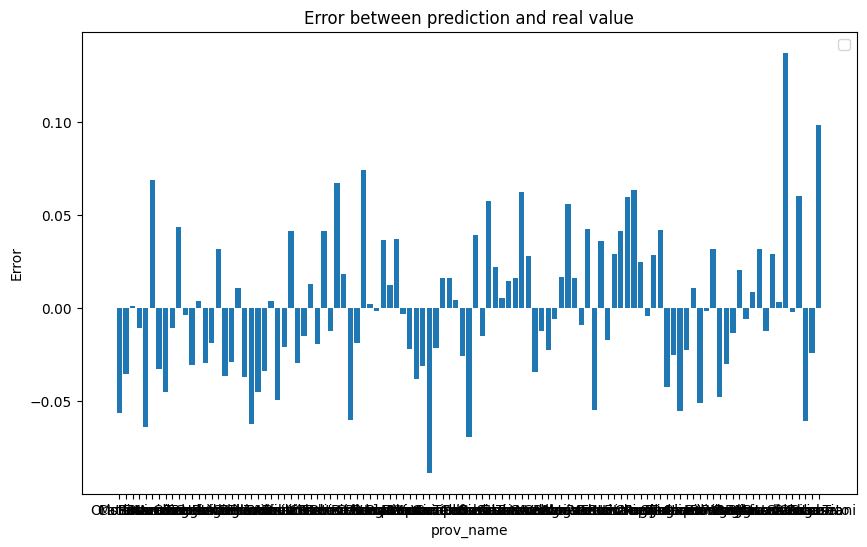

In [19]:
y_pred = lasso_final.predict(X_scaled)

Error=y_pred-y

# print(np.mean(Error**2))
# Graphique comparatif
plt.figure(figsize=(10,6))
# plt.boxplot(Error)
plt.bar(gdf["prov_name"],Error)
plt.xlabel("prov_name")
plt.ylabel("Error")
plt.title("Error between prediction and real value")
plt.legend()
plt.show()

# Bayes Lasso (Credits : Leo)

In [20]:
with pm.Model() as bl_model:
    X_data = pm.Data("X_data", X_scaled)
    y_data = pm.Data("y_data", y_scaled)

    lambda_ = pm.Gamma("lambda", alpha=0.1, beta=0.1)
    sigma = pm.HalfNormal("sigma", sigma=1.0)


    beta = pm.Laplace(
        "beta",
        mu=0.0,
        b=sigma / lambda_,
        shape=n_feat
    )


    mu = pm.math.dot(X_data, beta)

    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data)


    trace = pm.sample(
        draws=2000,
        tune=2000,
        target_accept=0.9,
        return_inferencedata=True,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lambda, sigma, beta]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/rich/live.py:256: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 40 seconds.


In [21]:
summary_beta = az.summary(trace, var_names=["beta"], hdi_prob=0.9)

summary_beta.index = selected_covariates

# summary_beta["contains_zero"] = (
#     (summary_beta["hdi_2.5%"] <= 0) &
#     (summary_beta["hdi_97.5%"] >= 0)
# )

summary_beta["contains_zero"] = (
    (summary_beta["hdi_5%"] <= 0) &
    (summary_beta["hdi_95%"] >= 0)
)

summary_beta = summary_beta.sort_values("mean", key=np.abs, ascending=False)

# print(summary_beta[["mean", "hdi_2.5%", "hdi_97.5%", "contains_zero"]])
print(summary_beta[["mean", "hdi_5%", "hdi_95%", "contains_zero"]])


                                     mean  hdi_5%  hdi_95%  contains_zero
empl_rate                           0.550   0.312    0.778          False
coverage                            0.108   0.002    0.209          False
ratio_edu_rate                      0.095   0.010    0.181          False
n_members_family                   -0.072  -0.169    0.027           True
graduate_mobility_rate              0.072  -0.032    0.212           True
young_neet                         -0.068  -0.173    0.037           True
ecec_diffusion                     -0.062  -0.133    0.015           True
per_capita_user_contribution        0.048  -0.039    0.143           True
per_capita_public_expenditure       0.043  -0.039    0.130           True
avg_children_per_woman             -0.036  -0.116    0.044           True
fem_maj_empl_rate                   0.031  -0.033    0.101           True
service_empl_rate                   0.028  -0.034    0.102           True
empl_growth                         0.

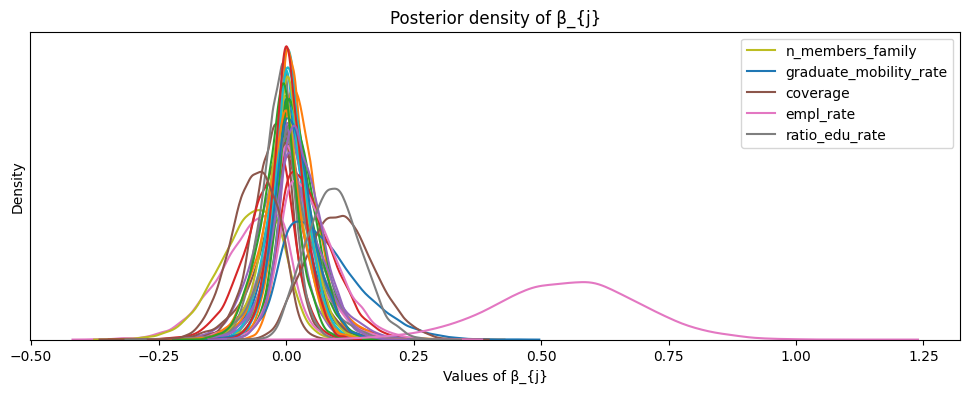

In [22]:
# az.rcParams["plot.max_subplots"] = 100   
# az.plot_trace(trace, compact=False)
# az.plot_trace(trace, var_names=["beta"])
# plt.tight_layout()

import matplotlib.pyplot as plt
import numpy as np

beta_samples = trace.posterior["beta"].stack(samples=("chain", "draw")).values

plt.figure(figsize=(12,4))

for i in range(beta_samples.shape[0]):
    if (selected_covariates[i] in ['empl_rate','coverage','ratio_edu_rate','n_members_family','graduate_mobility_rate']):
        sns.kdeplot(beta_samples[i, :],label=selected_covariates[i])
    else:
        sns.kdeplot(beta_samples[i, :])

plt.legend()
plt.title("Posterior density of β_{j}")
plt.xlabel("Values of β_{j}")
plt.yticks([])     
plt.gca().tick_params(axis='y', length=0)

plt.show()


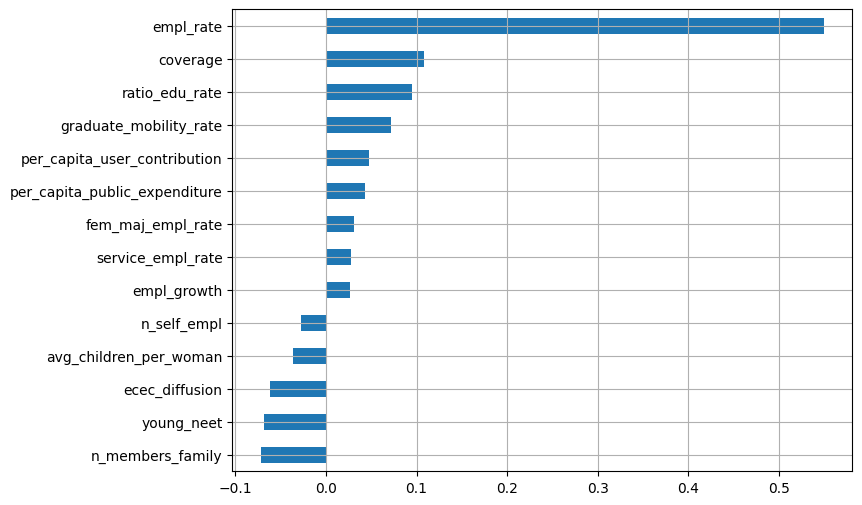

In [23]:
important_covariates=summary_beta[summary_beta["mean"].abs()>0.025]['mean']

plt.figure(figsize=(8,6))
important_covariates.sort_values().plot(kind='barh')
plt.grid(True)
plt.show()